In [1]:
# DMC toy model
# 1D Harmonic Oscillator

"""
Solve  H = -1/2 d^2/dx^2 + 1/2 x^2  in 1D and verify the eigenfunctions.

Two independent checks:
  (1) Diagonalize H as a finite-difference matrix -> eigenvalues should be n+1/2,
      eigenvectors should match the analytic Hermite functions (overlap ~ 1).
  (2) Direct: apply H to the *analytic* Hermite function and confirm
      H psi_n = (n+1/2) psi_n  (residual ~ 0).  This is the "is it really an
      eigenfunction" test, independent of the diagonalization.
"""

import numpy as np
from numpy.polynomial.hermite import hermval
from math import factorial, pi
import scipy.linalg as la

In [2]:
# numerical eigensolver
# ----------------------------------------------------------------------
# Grid.  L must be large enough that the wavefunctions are ~0 at the edges
# (Dirichlet box approximating the infinite domain); dx small for accuracy.
# ----------------------------------------------------------------------
L  = 10.0
N  = 2000
x  = np.linspace(-L, L, N)
dx = x[1] - x[0]

# ----------------------------------------------------------------------
# H as a symmetric tridiagonal matrix.
#   kinetic -1/2 d^2/dx^2  via the 3-point stencil
#        f'' -> (f_{i+1} - 2 f_i + f_{i-1}) / dx^2
#   so   -1/2 f''  has  diagonal +1/dx^2,  off-diagonal -1/(2 dx^2)
#   plus the potential 1/2 x^2 on the diagonal.
# ----------------------------------------------------------------------
main = 1.0 / dx**2 + 0.5 * x**2          # kinetic diag + potential
off  = -0.5 / dx**2 * np.ones(N - 1)     # kinetic off-diagonal

E, V = la.eigh_tridiagonal(main, off)    # ascending eigenvalues, orthonormal cols

# discrete eigenvectors satisfy sum(v^2)=1; continuum norm needs /sqrt(dx)
psi_num = V / np.sqrt(dx)

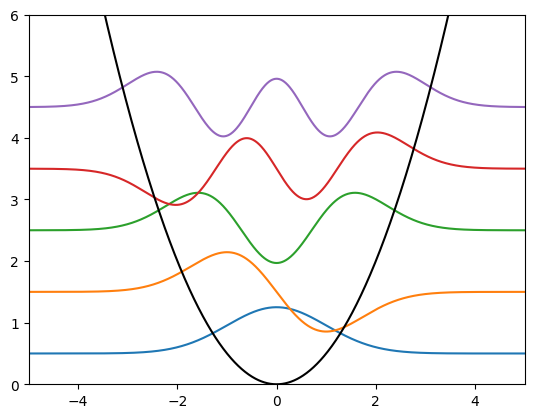

In [12]:
from matplotlib import pyplot as plt

plt.plot(x, psi_num[:,:5] + E[:5])
plt.plot(x, 0.5*x**2, 'k')
plt.ylim(0, 6)
plt.xlim(-5, 5)
plt.show()

In [3]:
# ----------------------------------------------------------------------
# Analytic eigenfunction:  psi_n = (2^n n! sqrt(pi))^{-1/2} H_n(x) e^{-x^2/2}
# ----------------------------------------------------------------------
def hermite_function(n, x):
    c = np.zeros(n + 1); c[n] = 1.0
    Hn = hermval(x, c) # physicists' Hermite H_n
    norm = (2.0**n * factorial(n) * np.sqrt(pi)) ** -0.5
    return norm * Hn * np.exp(-x**2 / 2)

# ----------------------------------------------------------------------
# Apply H to an arbitrary array (same finite-difference operator).
# ----------------------------------------------------------------------
def apply_H(psi, x, dx):
    lap = np.empty_like(psi)
    lap[1:-1] = (psi[2:] - 2*psi[1:-1] + psi[:-2]) / dx**2
    lap[0]    = (psi[1]  - 2*psi[0]) / dx**2          # psi=0 outside (Dirichlet)
    lap[-1]   = (psi[-2] - 2*psi[-1]) / dx**2
    return -0.5 * lap + 0.5 * x**2 * psi

# ======================================================================
# CHECK 1 — eigenvalues and eigenvector overlaps
# ======================================================================
print("CHECK 1:  diagonalized H vs analytic\n")
print(" n   E_numeric    E_exact   |overlap with Hermite|")
for n in range(6):
    psi_a = hermite_function(n, x)
    overlap = np.sum(psi_num[:, n] * psi_a) * dx     # sign-free magnitude below
    print(f" {n}   {E[n]:.6f}   {n+0.5:.6f}        {abs(overlap):.6f}")

# ======================================================================
# CHECK 2 — is the ANALYTIC function really an eigenfunction?
#   report max |H psi_n - (n+1/2) psi_n| in the bulk |x|<4
# ======================================================================
print("\nCHECK 2:  apply H to analytic psi_n, residual H psi - E psi\n")
bulk = np.abs(x) < 4.0
print(" n   max|H psi - (n+1/2) psi|   (should be ~ dx^2 small)")
for n in range(6):
    psi_a = hermite_function(n, x)
    res = apply_H(psi_a, x, dx) - (n + 0.5) * psi_a
    print(f" {n}   {np.max(np.abs(res[bulk])):.3e}")

print(f"\n(dx = {dx:.4f},  dx^2 = {dx**2:.2e})")

CHECK 1:  diagonalized H vs analytic

 n   E_numeric    E_exact   |overlap with Hermite|
 0   0.499997   0.500000        1.000000
 1   1.499984   1.500000        1.000000
 2   2.499959   2.500000        1.000000
 3   3.499922   3.500000        1.000000
 4   4.499872   4.500000        1.000000
 5   5.499809   5.500000        1.000000

CHECK 2:  apply H to analytic psi_n, residual H psi - E psi

 n   max|H psi - (n+1/2) psi|   (should be ~ dx^2 small)
 0   9.398e-06
 1   2.562e-05
 2   5.980e-05
 3   9.788e-05
 4   1.592e-04
 5   2.177e-04

(dx = 0.0100,  dx^2 = 1.00e-04)


In [9]:
np.arange(0, 10, 0.25)

array([0.  , 0.25, 0.5 , 0.75, 1.  , 1.25, 1.5 , 1.75, 2.  , 2.25, 2.5 ,
       2.75, 3.  , 3.25, 3.5 , 3.75, 4.  , 4.25, 4.5 , 4.75, 5.  , 5.25,
       5.5 , 5.75, 6.  , 6.25, 6.5 , 6.75, 7.  , 7.25, 7.5 , 7.75, 8.  ,
       8.25, 8.5 , 8.75, 9.  , 9.25, 9.5 , 9.75])

In [ ]:
# Deterministic Imaginary-Time Propagation
"""
Imaginary-time propagation of an initial guess on a real-space grid, using the
matrix exponential of the finite-difference Hamiltonian.

    phi(tau) = exp(-H tau) phi_0   ->   ground state as tau -> infinity
    (every eigencomponent decays as exp(-E_n tau); the slowest survivor is E_0)

Note: U = expm(-H dtau) is the EXACT propagator of the *discretized* H, so there
is NO time-step (Trotter) error here -- unlike split-operator or DMC.  The only
error is the spatial finite-difference discretization (~ dx^2).
"""

import numpy as np
import scipy.linalg as la

# ---- grid (same operator as the eigen-solver) ----
L  = 10.0
N  = 1000
x  = np.linspace(-L, L, N)
dx = x[1] - x[0]

# ---- H as a dense finite-difference matrix ----
main = 1.0 / dx**2 + 0.5 * x**2
off  = -0.5 / dx**2 * np.ones(N - 1)
H    = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

# ---- short-time propagator, computed ONCE and reused ----
dtau = 0.05
U    = la.expm(-dtau * H)            # exact exp of the discretized H

# ---- initial guess: an OFF-CENTER Gaussian (deliberately not the answer,
#      so it carries excited-state contamination to be filtered out) ----
phi  = np.exp(-(x - 1.5)**2)
phi /= np.sqrt(np.sum(phi**2) * dx)  # L2-normalize on the grid

def energy(p):
    """Variational energy estimator <p|H|p>/<p|p>."""
    return (p @ (H @ p)) / (p @ p)   # dx cancels in the ratio

# ---- propagate ----
nsteps = 300
snap_taus  = range(10, 0.25)   # times to snapshot phi
snap_steps = {int(round(t / dtau)): t for t in snap_taus}
taus, Es, snapshots = [0.0], [energy(phi)], {0: phi.copy()}
print(" tau      E(tau)        norm-rate E")
print(f"{0.0:5.2f}   {energy(phi):.6f}")
prev_lognorm = 0.0
for k in range(1, nsteps + 1):
    phi   = U @ phi
    nrm   = np.sqrt(np.sum(phi**2) * dx)
    # energy from the decay rate of the (un-renormalized) norm:
    #   ||phi|| ~ exp(-(E0) tau)  =>  E0 = -d ln||phi|| / dtau
    rate_E = -(np.log(nrm) - prev_lognorm) / dtau
    prev_lognorm = 0.0               # because we renormalize next line
    phi  /= nrm                      # renormalize (keeps amplitudes O(1))
    # if k % 30 == 0 or k <= 3:
    #     print(f"{k*dtau:5.2f}   {energy(phi):.6f}     {rate_E:.6f}")
    if k in snap_steps:
        print(f"{k*dtau:5.2f}   {energy(phi):.6f}     {rate_E:.6f}")
        snapshots[k] = phi.copy()

print(f"\nfinal  E = {energy(phi):.6f}   (exact ground state = 0.5)")

# overlap of the relaxed state with exp(-x^2/2) (the analytic ground state)
psi0  = np.exp(-x**2 / 2); psi0 /= np.sqrt(np.sum(psi0**2) * dx)
print(f"|<phi|psi0>| = {abs(np.sum(phi*psi0)*dx):.6f}   (should be ~1)")

 tau      E(tau)        norm-rate E
 0.00   1.749950
 0.05   1.668198     1.708655
 0.10   1.591037     1.629267
 0.15   1.517826     1.554120
 1.50   0.596623     0.601461
 3.00   0.504939     0.505194
 4.50   0.500234     0.500247
 6.00   0.500000     0.500000
 7.50   0.499988     0.499988
 9.00   0.499988     0.499988
10.50   0.499987     0.499987
12.00   0.499987     0.499987
13.50   0.499987     0.499987
15.00   0.499987     0.499987

final  E = 0.499987   (exact ground state = 0.5)
|<phi|psi0>| = 1.000000   (should be ~1)


In [12]:
"""
Visualize imaginary-time relaxation:
  (left)  the wavefunction phi(x,tau) morphing from the initial guess into the
          ground state e^{-x^2/2}
  (right) the energy E(tau) decaying to the exact ground-state energy 1/2
"""

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

# ---- grid + Hamiltonian (same operator as before) ----
L  = 8.0
N  = 800
x  = np.linspace(-L, L, N)
dx = x[1] - x[0]

main = 1.0 / dx**2 + 0.5 * x**2
off  = -0.5 / dx**2 * np.ones(N - 1)
H    = np.diag(main) + np.diag(off, 1) + np.diag(off, -1)

dtau = 0.05
U    = la.expm(-dtau * H)

def energy(p):
    return (p @ (H @ p)) / (p @ p)

# ---- exact ground state for reference ----
psi0 = np.exp(-x**2 / 2)
psi0 /= np.sqrt(np.sum(psi0**2) * dx)

In [23]:
# ---- initial guess: off-center Gaussian (carries excited-state contamination) ----
phi  = -np.sin(x) * np.exp(-(x+3)**2)
phi /= np.sqrt(np.sum(phi**2) * dx)

# ---- propagate, recording E(tau) and snapshots at selected tau ----
nsteps     = 300
snap_taus  = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]   # times to snapshot phi
snap_steps = {int(round(t / dtau)): t for t in snap_taus}

taus, Es, snapshots = [0.0], [energy(phi)], {0: phi.copy()}
print(" tau      E(tau)        norm-rate E")
print(f"{0.0:5.2f}   {energy(phi):.6f}")
for k in range(1, nsteps + 1):
    phi  = U @ phi
    phi /= np.sqrt(np.sum(phi**2) * dx)
    taus.append(k * dtau)
    Es.append(energy(phi))
    if k in snap_steps:
        snapshots[k] = phi.copy()
        print(f"{k*dtau:5.2f}   {energy(phi):.6f}     {rate_E:.6f}")

taus = np.array(taus); Es = np.array(Es)

 tau      E(tau)        norm-rate E
 0.00   5.887516
 0.25   3.126962     0.499987
 0.50   2.230334     0.499987
 1.00   1.293968     0.499987
 2.00   0.622423     0.499987
 4.00   0.502277     0.499987
 8.00   0.499988     0.499987


saved figure
final E = 0.499987   |<phi|psi0>| = 1.000000


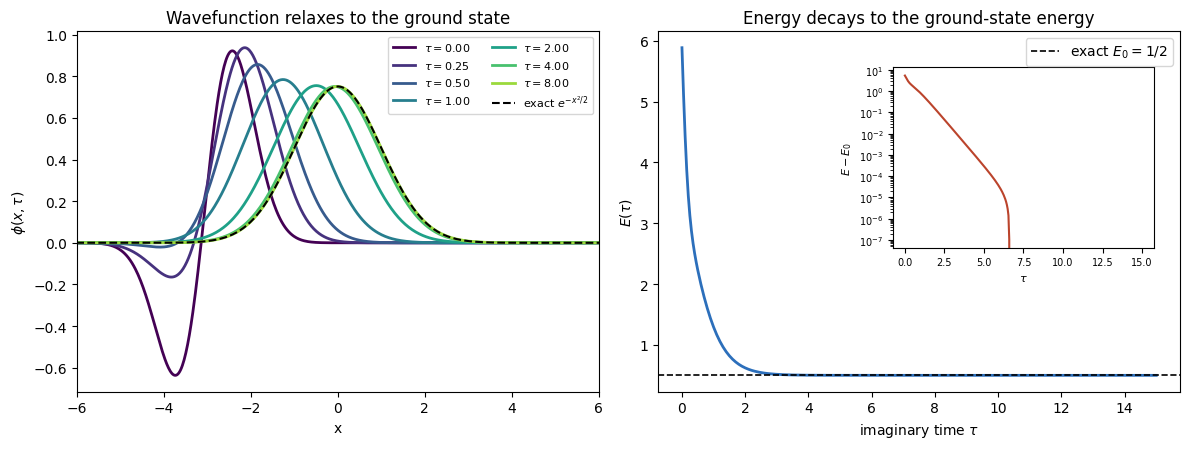

In [24]:
# ====================================================================
# PLOT
# ====================================================================
E0 = 0.5

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))

# --- left: wavefunction snapshots, colored light->dark with increasing tau ---
cmap = plt.cm.viridis
keys = sorted(snapshots.keys())
for i, k in enumerate(keys):
    frac = i / (len(keys) - 1)
    axL.plot(x, snapshots[k], color=cmap(0.85 * frac),
             lw=2, label=fr"$\tau={k*dtau:.2f}$")
axL.plot(x, psi0, 'k--', lw=1.5, label=r"exact $e^{-x^2/2}$")
axL.set_xlim(-6, 6)
axL.set_xlabel("x"); axL.set_ylabel(r"$\phi(x,\tau)$")
axL.set_title("Wavefunction relaxes to the ground state")
axL.legend(fontsize=8, ncol=2)

# --- right: energy convergence ---
axR.plot(taus, Es, lw=2, color="#2c6fbb")
axR.axhline(E0, color="k", ls="--", lw=1.2, label=r"exact $E_0=1/2$")
axR.set_xlabel(r"imaginary time $\tau$"); axR.set_ylabel(r"$E(\tau)$")
axR.set_title("Energy decays to the ground-state energy")
axR.legend(fontsize=10)

# inset: log-scale of (E - E0) to expose the exponential approach
axins = axR.inset_axes([0.45, 0.40, 0.5, 0.5])
axins.semilogy(taus, Es - E0, color="#bb442c", lw=1.5)
axins.set_xlabel(r"$\tau$", fontsize=8)
axins.set_ylabel(r"$E-E_0$", fontsize=8)
axins.tick_params(labelsize=7)

plt.tight_layout()
print("saved figure")
print(f"final E = {Es[-1]:.6f}   |<phi|psi0>| = {abs(np.sum(phi*psi0)*dx):.6f}")